<a href="https://colab.research.google.com/github/Nishanthini03/DeepLearning/blob/branch1/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Simple Linear Regression**



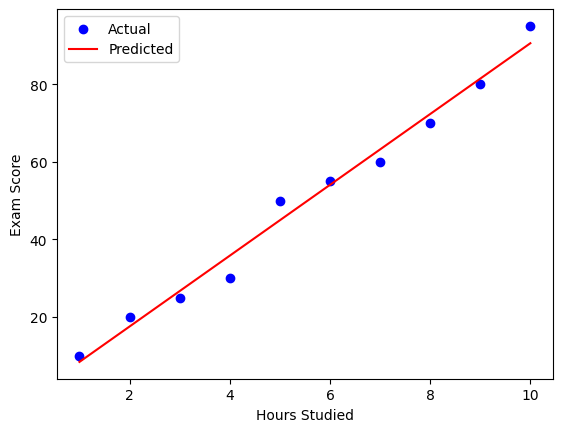

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample data: Hours studied vs. Exam Score
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
Y = np.array([10, 20, 25, 30, 50, 55, 60, 70, 80, 95])

# Create and train the model
model = LinearRegression()
model.fit(X, Y)

# Predict
Y_pred = model.predict(X)

# Visualization
plt.scatter(X, Y, color='blue', label="Actual")
plt.plot(X, Y_pred, color='red', label="Predicted")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.show()


# **Multiple Linear Regression**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Sample dataset
data = {
    "Size": [1500, 1800, 2400, 3000, 3500],
    "Bedrooms": [3, 4, 4, 5, 5],
    "Age": [10, 5, 15, 20, 7],
    "Price": [200, 250, 280, 310, 350]  # Target variable
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Features (X) and target (Y)
X = df[["Size", "Bedrooms", "Age"]]
Y = df["Price"]

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, Y_train)

# Make predictions
Y_pred = model.predict(X_test)

# Model evaluation
mse = mean_squared_error(Y_test, Y_pred)
print(f"Mean Squared Error: {mse}")

# Print model coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Mean Squared Error: 10677.777777777774
Intercept: 176.66666666666652
Coefficients: [  0.16666667 -86.66666667   3.33333333]


# **Polynomial Regression**

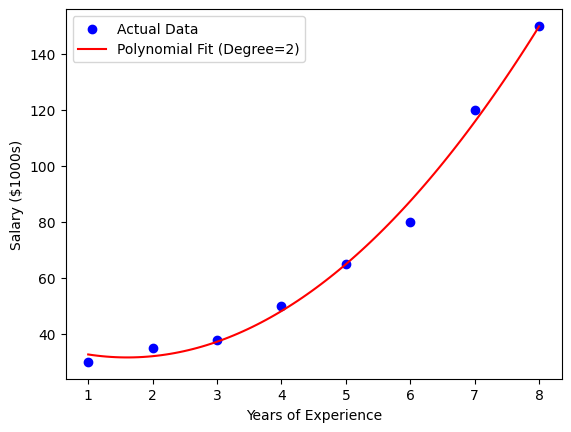

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Sample dataset (Experience in years vs. Salary)
X = np.array([1, 2, 3, 4, 5, 6, 7, 8]).reshape(-1, 1)
Y = np.array([30, 35, 38, 50, 65, 80, 120, 150])  # Salary in $1000s

# Transform features to polynomial (degree = 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Train polynomial regression model
model = LinearRegression()
model.fit(X_poly, Y)

# Predict
X_test = np.linspace(1, 8, 100).reshape(-1, 1)  # Generating test data
X_test_poly = poly.transform(X_test)
Y_pred = model.predict(X_test_poly)

# Visualization
plt.scatter(X, Y, color='blue', label="Actual Data")
plt.plot(X_test, Y_pred, color='red', label="Polynomial Fit (Degree=2)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary ($1000s)")
plt.legend()
plt.show()


## **Ridge & Lasso Regression**

Linear Regression MSE: 7.35504492928843
Ridge Regression MSE: 7.345985139930247
Lasso Regression MSE: 7.3302384340969535


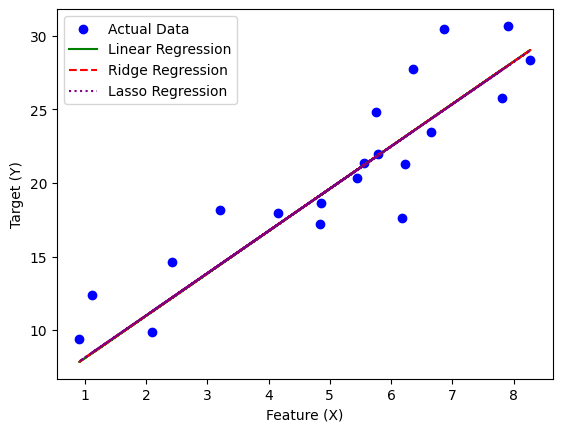

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Sample dataset
X = np.random.rand(100, 1) * 10  # Random data (100 points)
Y = 3 * X.squeeze() + 5 + np.random.randn(100) * 3  # Linear relationship with noise

# Split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Train models
lr = LinearRegression().fit(X_train, Y_train)
ridge = Ridge(alpha=1).fit(X_train, Y_train)  # Regularization parameter λ=1
lasso = Lasso(alpha=0.1).fit(X_train, Y_train)  # Regularization parameter λ=0.1

# Predictions
Y_pred_lr = lr.predict(X_test)
Y_pred_ridge = ridge.predict(X_test)
Y_pred_lasso = lasso.predict(X_test)

# Print errors
print("Linear Regression MSE:", mean_squared_error(Y_test, Y_pred_lr))
print("Ridge Regression MSE:", mean_squared_error(Y_test, Y_pred_ridge))
print("Lasso Regression MSE:", mean_squared_error(Y_test, Y_pred_lasso))

# Plot results
plt.scatter(X_test, Y_test, color='blue', label="Actual Data")
plt.plot(X_test, Y_pred_lr, color='green', label="Linear Regression")
plt.plot(X_test, Y_pred_ridge, color='red', linestyle="dashed", label="Ridge Regression")
plt.plot(X_test, Y_pred_lasso, color='purple', linestyle="dotted", label="Lasso Regression")
plt.xlabel("Feature (X)")
plt.ylabel("Target (Y)")
plt.legend()
plt.show()


**SVM**

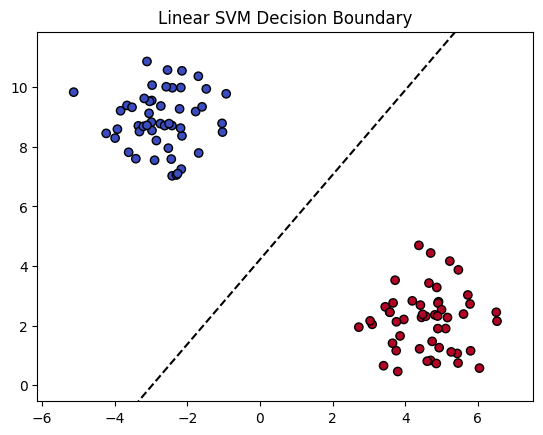

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

# Generate sample data
X, y = make_blobs(n_samples=100, centers=2, random_state=42)

# Train SVM Model
model = SVC(kernel='linear')
model.fit(X, y)

# Plot decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.contour(xx, yy, Z, levels=[0], colors='black', linestyles='dashed')
plt.title("Linear SVM Decision Boundary")
plt.show()


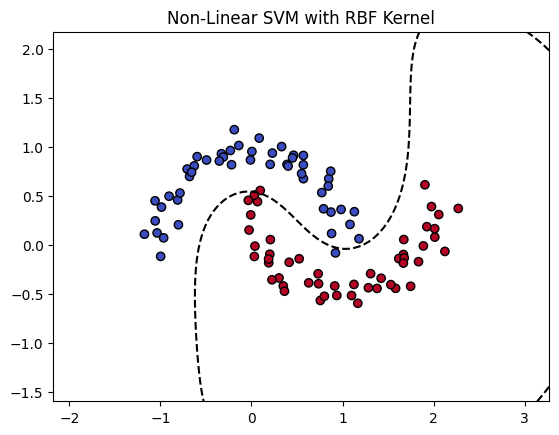

In [ ]:
from sklearn.svm import SVC
from sklearn.datasets import make_moons

# Generate non-linearly separable data
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

# Train Non-Linear SVM with RBF Kernel
model = SVC(kernel='rbf', gamma='scale')
model.fit(X, y)

# Plot decision boundary
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 100))
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.contour(xx, yy, Z, levels=[0], colors='black', linestyles='dashed')
plt.title("Non-Linear SVM with RBF Kernel")
plt.show()
